In [ ]:
import numpy as np
import numpy.polynomial.polynomial as poly
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mp

from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

from google.colab import drive
from google.colab import files


In [ ]:
# Mount Drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/Astley equation paper/all_fe_data_updated.csv')
df1



,Tn,ID,SVL,Mass,Reference,Type,Frame,Wrap,Axial,Linear GS,Linear CE,PredPitch,PredBuck
0,9,2018DP01,113.900000,185.1,1498,NC,1401.0,No,No,54.771547,40.356339,65.303897,0.115559
1,10,2018DP01,113.900000,185.1,1,NC,865.0,Simple,No,49.378708,45.732052,65.303897,0.115559
2,11,2018DP01,113.900000,185.1,1,NC,365.0,No,No,51.769641,41.407394,65.303897,0.115559
3,12,2018DP01,113.900000,185.1,1120,Success,1120.0,No,No,50.544311,52.827253,65.303897,0.115559
4,14,2018DP01,113.900000,185.1,847,NC,1494.0,No,No,54.747748,43.086014,65.303897,0.115559
...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,374,2019DP20,89.495333,133.4,10518,NC,13070.0,Not visibly,No,41.687515,33.163610,51.311625,0.080526
205,375,2019DP20,89.495333,133.4,1000,NC,3274.0,Not visibly,No,43.771067,25.358365,51.311625,0.080526
206,376,2019DP20,89.495333,133.4,32660,NC,35008.0,Not visibly,No,43.835034,33.663510,51.311625,0.080526
207,377,2019DP20,89.495333,133.4,5789,NC,6038.0,Not visibly,No,45.804744,29.595868,51.311625,0.080526


# Figure 6D

In [ ]:
df = df1[(df1['Type']!="Success")&(df1['Type']!="NC")].copy()
df.sort_values('SVL',inplace=True)

In [ ]:
#create combination options - tail wrap (TW) only, axial reorientation (AR) only, neither, or both.

#First, clean up the TW and AR columns to make it binary
df['tail_wrap_binary'] = ~df['Wrap'].isin(['No', 'Not visibly'])
df['axial_reorientation_binary'] = df['Axial'] == 'Yes'

# Then create the behavior category
conditions = [
    df['tail_wrap_binary'] & df['axial_reorientation_binary'],
    df['tail_wrap_binary'] & ~df['axial_reorientation_binary'],
    ~df['tail_wrap_binary'] & df['axial_reorientation_binary'],
    ~df['tail_wrap_binary'] & ~df['axial_reorientation_binary']
]

choices = ['Both', 'TW only', 'AR only', 'None']

df['clean_beh'] = np.select(conditions, choices, default='None')

In [ ]:
#now clean up failure type
df['clean_fail'] = df['Type'].replace({
    'drop': 'Drop',
    'PB/Drop': 'Drop',
    'PB/Drop?': 'Drop',
    'PB': 'PB',
    'Pitch': 'Pitch',
    'PB/Pitch?': 'PB'
})


In [ ]:
df['Distance_pct_SVL'] = (df['Linear CE'] / df['SVL']) * 100

# Define marker styles based on behavior type
def get_marker_style(behavior):
    if behavior == 'None':
        return 'o', 'full'  # circle, filled
    elif behavior == 'Both':
        return 'd', 'full'  # diamond, filled
    elif behavior == 'TW only':
        return 'v', 'full'  # triangle down, filled
    elif behavior == 'AR only':
        return '^', 'full'  # triangle up, filled

fail_color = "#CC2132"

# Define colors based on failure type
def get_color(failure):
    if failure == 'Pitch':
        return fail_color, 1, 'k'
    elif failure == 'PB':
        return fail_color, 0.2, fail_color
    elif failure == 'Drop':
        return fail_color, 0.6, fail_color

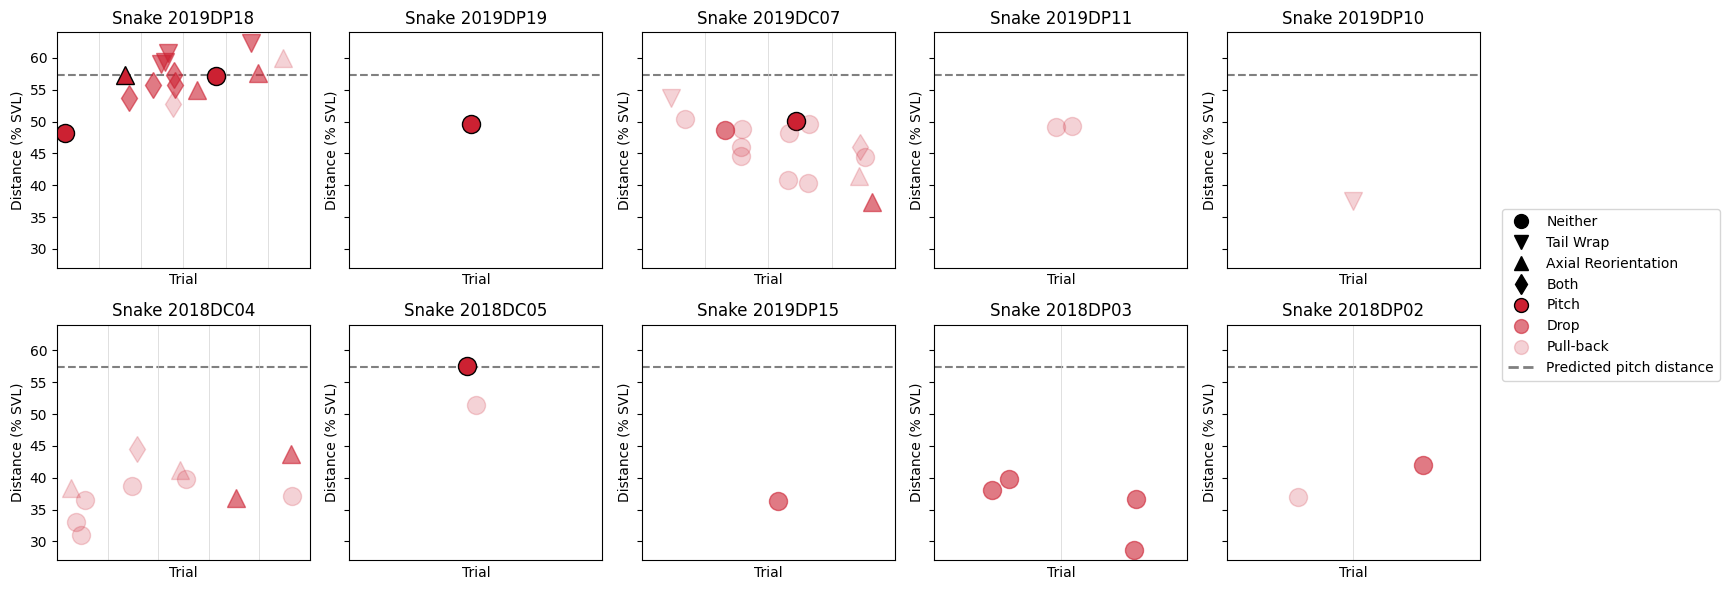

In [ ]:
# Create subplots
snake_ids = df['ID'].unique()
fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharex=False, sharey=True)
axes = axes.flatten()

for idx, snake_id in enumerate(snake_ids):
    snake_data = df[df['ID'] == snake_id]

    # Get unique trials in order and create mapping to evenly spaced positions
    unique_trials = sorted(snake_data['Tn'].unique())
    n_trials = len(unique_trials)

    if n_trials == 1:
        trial_to_x = {unique_trials[0]: 0.5}
    else:
        positions = [(i + 0.5) / n_trials for i in range(n_trials)]
        trial_to_x = dict(zip(unique_trials, positions))

    # Add vertical lines at trial boundaries
    for i in range(1, n_trials):
        boundary_x = i / n_trials
        axes[idx].axvline(x=boundary_x, color='lightgrey', linestyle='-', linewidth=0.5)

    # Plot each point with jitter
    for _, row in snake_data.iterrows():
        marker, fillstyle = get_marker_style(row['clean_beh'])
        color, alpha, edge_color = get_color(row['clean_fail'])

        base_x = trial_to_x[row['Tn']]
        jitter = np.random.uniform(-0.05, 0.05)

        axes[idx].plot(base_x + jitter, row['Distance_pct_SVL'],
                      marker=marker, fillstyle=fillstyle, alpha=alpha,
                      color=color, markersize=13, markeredgecolor=edge_color)

    axes[idx].axhline(y=57.33, color="grey", linestyle="--", zorder=0)
    axes[idx].set_title(f'Snake {snake_id}')
    axes[idx].set_xlabel('Trial')
    axes[idx].set_ylabel('Distance (% SVL)')
    axes[idx].set_xlim(0, 1)
    axes[idx].set_xticks([])

# Create custom legend
behavior_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markeredgecolor='black', markersize=10, label='Neither'),
    Line2D([0], [0], marker='v', color='w', markerfacecolor='black', markeredgecolor='black', markersize=10, label='Tail Wrap'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='black', markeredgecolor='black', markersize=10, label='Axial Reorientation'),
    Line2D([0], [0], marker='d', color='w', markerfacecolor='black', markeredgecolor='black', markersize=10, label='Both')
]

failure_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=fail_color, markeredgecolor='k', markersize=10, label='Pitch'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=fail_color, markeredgecolor=fail_color, markersize=10, label='Drop', alpha = 0.6),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=fail_color, markeredgecolor=fail_color, markersize=10, label='Pull-back', alpha = 0.2)
]

other_legend = [
    Line2D([0], [0], color='grey', linestyle='--', linewidth=2, label='Predicted pitch distance')
]

# Combine all legend elements
all_legend = behavior_legend + failure_legend + other_legend

# Add legend to the figure (outside the subplots)
fig.legend(handles=all_legend, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

plt.tight_layout()
plt.show()

In [ ]:
fig.savefig('all_fails.pdf', bbox_inches='tight')
files.download('all_fails.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Figure 6B - All max extents, dendrelaphis

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Astley equation paper/fe_summary_forFig6.csv')
df.head()

#clean up failure type
df['clean_fail'] = df['Itype'].replace({
    'drop': 'Drop',
    'PB/Drop': 'Drop',
    'PB/Drop?': 'Drop',
    'PB': 'PB',
    'Pitch': 'Pitch',
    'PB/Pitch?': 'PB'
})

#clean up behavioral categories
#create combination options - tail wrap (TW) only, axial reorientation (AR) only, neither, or both.

#First, clean up the TW and AR columns to make it binary
df['tail_wrap_binary'] = ~df['Wrap'].isin(['No', 'Not visibly'])
df['axial_reorientation_binary'] = df['Axial'] == 'Yes'

# Then create the behavior category
conditions = [
    df['tail_wrap_binary'] & df['axial_reorientation_binary'],
    df['tail_wrap_binary'] & ~df['axial_reorientation_binary'],
    ~df['tail_wrap_binary'] & df['axial_reorientation_binary'],
    ~df['tail_wrap_binary'] & ~df['axial_reorientation_binary']
]

choices = ['Both', 'TW only', 'AR only', 'None']

df['clean_beh'] = np.select(conditions, choices, default='None')

#create log columns
df['log(svl)'] = np.log10(df['SVL (cm)'])
df['log(extent)'] = np.log10(df['Extent (cm)'])
df['logPitch'] = np.log10(df['PredPitch'])


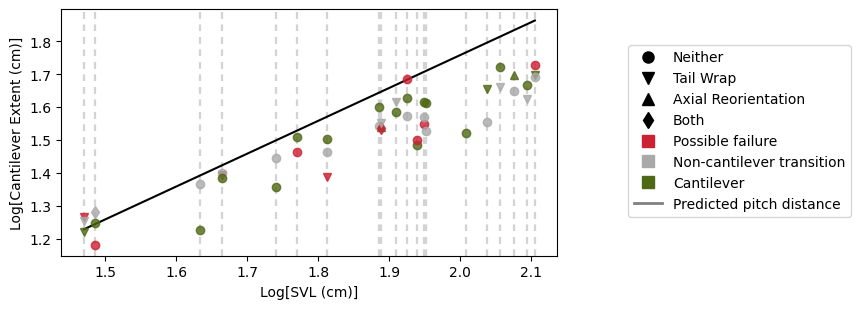

In [ ]:
#Dendrelaphis: graph of max cantilever extent in each type
fig, ax = plt.subplots(figsize=(6.4, 3.2))  # width, height in inches


# Define marker styles based on behavior type
def get_marker_style(behavior):
    if behavior == 'None':
        return 'o'  # circle
    elif behavior == 'Both':
        return 'd'  # diamond
    elif behavior == 'TW only':
        return 'v' # triangle down
    elif behavior == 'AR only':
        return '^'  # triangle up

def get_fill_style(thing):
  if thing == 'Cantilever':
    return '#4F6815', 'full'
  elif thing == 'NC':
    return 'darkgrey', 'full'
  elif thing == 'Incomplete':
    return '#CC2132', 'full'

for _, row in df.iterrows():
    marker = get_marker_style(row['clean_beh'])
    color, fillstyle = get_fill_style(row['Type'])

    ax.plot(row['log(svl)'], row['log(extent)'], marker=marker, color=color, fillstyle=fillstyle, alpha=0.8)



df=df.sort_values(by=['log(svl)'])
pitch_df = df.dropna(subset=['logPitch'])
ax.plot(pitch_df['log(svl)'], pitch_df['logPitch'], '-', label='Predicted Pitch', zorder=1, c="k")


ax.set_xlabel("Log[SVL (cm)]")
ax.set_ylabel("Log[Cantilever Extent (cm)]")

trans = ax.get_xaxis_transform()

for i in range(0,len(df['log(svl)'])):
    ax.axvline(df['log(svl)'][i],c='#D3D3D3',zorder=0,dashes=[3,3])


behavior_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markeredgecolor='black', markersize=8, label='Neither'),
    Line2D([0], [0], marker='v', color='w', markerfacecolor='black', markeredgecolor='black', markersize=8, label='Tail Wrap'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='black', markeredgecolor='black', markersize=8, label='Axial Reorientation'),
    Line2D([0], [0], marker='d', color='w', markerfacecolor='black', markeredgecolor='black', markersize=8, label='Both')
]

type_legend = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#CC2132', markeredgecolor='#CC2132', markersize=8, label='Possible failure'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='darkgrey', markeredgecolor='darkgrey', markersize=8, label='Non-cantilever transition'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#4F6815', markeredgecolor='#4F6815', markersize=8, label='Cantilever')
]

other_legend = [
    Line2D([0], [0], color='grey', linestyle='-', linewidth=2, label='Predicted pitch distance')
]

# Combine all legend elements
all_legend = behavior_legend + type_legend + other_legend

# Add legend to the figure (outside the subplots)
fig.legend(handles=all_legend, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

In [ ]:
fig.savefig('all_farthest_extents.pdf', bbox_inches='tight')
files.download('all_farthest_extents.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# Figure 6C: Chrysopelea max extents

In [ ]:
import dill

In [ ]:
#import Chrysopelea data

cp = pd.read_csv('/content/drive/MyDrive/Astley equation paper/cp_data.csv')
with open('/content/drive/MyDrive/Astley equation paper/smooth_pos_v8.pkl', 'rb') as f:
    sm_pos = dill.load(f)

with open('/content/drive/MyDrive/Astley equation paper/raw_dictionaries_v9.pkl', 'rb') as f:
    all_imported = dill.load(f)

sm_pos = [i/10 for i in sm_pos] #change from mm to cm
CP_com = 0.5320842051561528

In [ ]:
#identify linear extent at landing (cantilevers), or transition/acceleration (non-cantilevers), or failure point (3 trials snake 89)

farthest = []
snakeID = []
svls = []
trials = []

for i in np.arange(len(all_imported)):
    tn = all_imported[i]['tn']
    ind = np.where(cp['tn'].values == tn)[0][0]
    trials.append(tn)
    snakeID.append(all_imported[i]['ID'])
    svls.append(all_imported[i]['svl']) #in cm

    if np.isnan(all_imported[i]['oe'][0]):
        origin = sm_pos[i][0,0,:] #use head position at start of trial as substitute for missing origin marker
        snake = sm_pos[i] - origin #subtract origin to make all positions relative to that point
    else:
        snake = sm_pos[i]

    if cp['bcode'][ind]==0: #selects all cantilever trials
        FEp = np.linalg.norm(snake[-1,0,:]) #is relative to origin = 0,0,0; position at landing
    else: #non-cantilever trials + cantilever failures, where transition frame is failure frame.
        tf = cp['transition'][ind]
        if not np.isnan(tf):
            tf = int(tf)
            find = np.where(all_imported[i]['fn'] == tf)[0][0] #position at transition frame
            FEp = np.linalg.norm(snake[find,0,:])
        else:
            FEp = np.nan

    farthest.append(FEp)

In [ ]:
#Collect data: max NC transition extent, failure extent, Max cantilever success, pitchpoint
snakeID = np.array([str(int(item)) for item in snakeID])
x_vals = np.unique(np.array(snakeID))
cp_sum = pd.DataFrame(x_vals,columns=["Snake ID"])
all_cp_trials = list(cp['tn'].values)

for n in np.arange(len(x_vals)):
    each = x_vals[n]
    spots = np.where(snakeID==each)[0]
    extents = np.array(farthest)[spots]
    trial_set = np.array(trials)[spots]

    c_extents = []
    f_extents = []
    nct_extents = []

    for tn in trial_set:
        ind1 = all_cp_trials.index(tn)
        ind2 = list(trial_set).index(tn)

        beh = cp['bcode'][ind1]
        if beh==0:
            c_extents.append(extents[ind2])
        elif beh==2:
            f_extents.append(extents[ind2])
        else:
            nct_extents.append(extents[ind2])

    max_cant = max(c_extents)
    max_trans = max(nct_extents)

    if f_extents:
        max_fail = max(f_extents)
        print(f_extents)
    else:
        max_fail = np.nan

    max_overall = max(max_cant,max_trans,max_fail)

    svl = np.max(np.array(svls)[spots])
    pitchpoint = svl*CP_com  #svl entries should all be the same for a given snake so max should just pick out one of the values

    cp_sum.at[n,'svl'] = svl
    cp_sum.at[n,'cmax'] = max_cant
    cp_sum.at[n,'tmax'] = max_trans
    cp_sum.at[n,'fmax'] = max_fail
    cp_sum.at[n,'omax'] = max_overall
    cp_sum.at[n,'pitch'] = pitchpoint

    cp_sum.at[n,'logc'] = np.log10(max_cant)
    cp_sum.at[n,'logf'] = np.log10(max_fail)
    cp_sum.at[n,'logt'] = np.log10(max_trans)
    cp_sum.at[n,'logo'] = np.log10(max_overall)
    cp_sum.at[n,'logp'] = np.log10(pitchpoint)
    cp_sum.at[n,'logs'] = np.log10(svl)

    #all these data are in cm

cp_sum

[np.float64(38.14759281172584), np.float64(34.72323957048249)]


,Snake ID,svl,cmax,tmax,fmax,omax,pitch,logc,logf,logt,logo,logp,logs
0,85,72.5,33.832180,34.819898,NaN,34.819898,38.576105,1.529330,NaN,1.541827,1.541827,1.586318,1.860338
1,88,95.9,42.538964,38.626966,NaN,42.538964,51.026875,1.628787,NaN,1.586891,1.628787,1.707799,1.981819
2,89,73.5,38.119584,34.617022,38.147593,38.147593,39.108189,1.581148,1.581467,1.539290,1.581467,1.592268,1.866287
3,90,72.5,30.795611,32.069798,NaN,32.069798,38.576105,1.488489,NaN,1.506096,1.506096,1.586318,1.860338
4,94,85.0,40.592697,35.707279,NaN,40.592697,45.227157,1.608448,NaN,1.552757,1.608448,1.655399,1.929419
5,95,66.7,34.329003,31.648745,NaN,34.329003,35.490016,1.535661,NaN,1.500356,1.535661,1.550106,1.824126


Text(0, 0.5, 'Log[Cantilever Extent (cm)]')

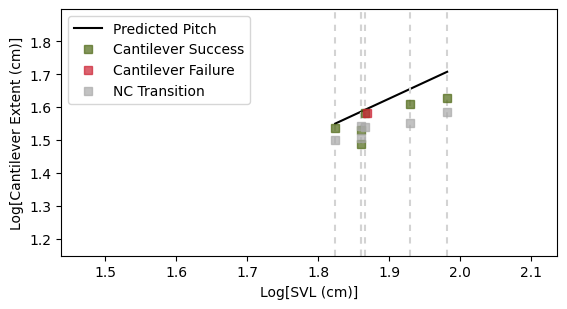

In [ ]:
#graphs similar to ones for Dendrelaphis; showing SVL on X axis, pitch point/FEs on Y axis with indication of whether NC transition or cantilever landing
#colors = ["#52FFB8","#0B3954","#F44174"]
colors = ["#4F6815","#CC2132","darkgrey"]
cp_sum.sort_values(by='logs', ascending=True, inplace=True)
fig,ax = plt.subplots(figsize=(6.4, 3.2))

ax.plot(cp_sum['logs'],cp_sum['logp'],'-',label='Predicted Pitch',zorder=1,c="k")
ax.plot(cp_sum['logs'],cp_sum['logc'],'s',label='Cantilever Success',color=colors[0],alpha=0.7)
ax.plot(cp_sum['logs']+0.002,cp_sum['logf'],'s',label='Cantilever Failure',color=colors[1],alpha=0.7)
ax.plot(cp_sum['logs'],cp_sum['logt'],'s',label='NC Transition',color=colors[2],alpha=0.7)

trans = ax.get_xaxis_transform()

for i in range(0,len(cp_sum['logs'])):
    ax.axvline(cp_sum['logs'][i],c='#D3D3D3',zorder=1,dashes=[3,3])
    # ax.text(cp_sum['logs'][i],1.01,cp_sum['Snake ID'][i],rotation=40,color="#D3D3D3",transform=trans)

ax.legend(ncol=1)
ax.set_xlim(xmin,xmax)
ax.set_ylim(ymin,ymax)
ax.set_xlabel("Log[SVL (cm)]")
ax.set_ylabel("Log[Cantilever Extent (cm)]")

# ax.set_ylim(2,4.1)

In [ ]:
fig.savefig('CP_max_extents.pdf', bbox_inches='tight')
files.download('CP_max_extents.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>